Question 6.1 : FITS file analysis

Filename: ./Downloads/m101(1).fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530
This data structure is a: <class 'numpy.ndarray'>
Its shape should be (NAXIS2, NAXIS1): True

May share memory: True
Min. and max. data values: 1507 15752
N=280900 min=1507, max=15752, mean=4795.924268422927, std=1848.2558984219054
Mode of the data: 3551 with 876 counts
Median of the data: 4102.0


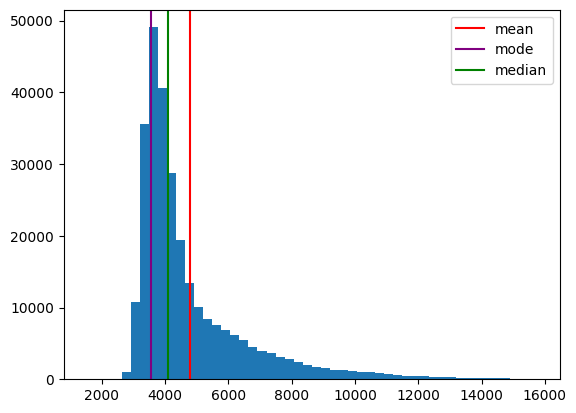

the median of y is 4102.0


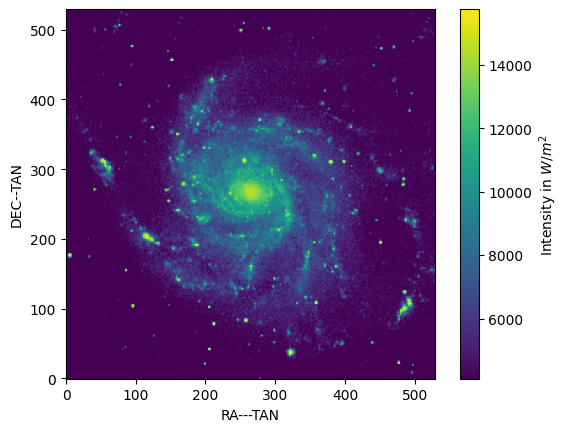

In [13]:
from imageio import imwrite, imread
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
hdulist = fits.open("./Downloads/m101(1).fits") # Open the image in the correct directory
hdulist.info() #get its information
#How many HDU’s are in this FITS file? There a two (0 and 1)
#Which HDU contains the image data? What is the index of that HDU in the list? The first one (with index 0)
#What is the number type of the data? int16

hdr = hdulist[0].header
for key in hdr[:5]:
    print(f"{key:18s}= {hdr[key]}")

#The value of BITPIX=16, this corresponds to our datatype that asks for 16 integers.

dat = hdulist[0].data
print("This data structure is a:", type(dat))
print("Its shape should be (NAXIS2, NAXIS1):", (hdr['NAXIS2'], hdr['NAXIS1']) == dat.shape)

print("\nMay share memory:", np.may_share_memory(dat,hdulist[0].data))
print("Min. and max. data values:", dat.min(), dat.max())

# What is the shape of the NumPy array dat? It is NAXIS2, NAXIS1, so 530 by 530
# Does this correspond to the information returned with info()? Yes, the header shows that there are two dimensions
# (530,530)
# Does it correspond to the values of the NAXIS keywords in the header? Yes, that shows that there are two NAXIS
# NAXIS1 a value f 530 and NAXIS2 with a value of 530
# What is the contents of the attribute dtype of the array dat? int16
# Check online for the meaning of dtype. Does it correspond to the value in BITPIX=? 
# Yes because there are 16 integers 

from scipy import stats
flatdat = dat.flatten() #flatten the data
nobs, (minval, maxval), mean, var, skew, kurt = stats.describe(dat.flat)
print(f"N={nobs} min={minval}, max={maxval}, mean={mean}, std={var**0.5}") #Give the statosycs information

mode, counts = stats.mode(dat.flat)
print(f"Mode of the data: {mode} with {counts} counts") #Give the mode

median = np.median(dat.flat)
print(f"Median of the data: {median}") #Give the median

plt.figure() #Make a new figure
plt.hist(flatdat, bins=50)  #As an histogram, with 50 bins

plt.axvline(x=mean, color='red', label= 'mean') #Create vertical lines at the three points
plt.axvline(x=mode, color='purple', label= 'mode')
plt.axvline(x=median, color='green', label= 'median')
plt.legend()
plt.show()

medd= np.median(np.asarray(dat)) #make an array of the data
print("the median of y is", medd) #calculate the median again
fig = figure()
frame = fig.add_subplot(1,1,1) #add the picture
img = frame.imshow(np.asarray(dat), interpolation='none', origin="lower", vmin=medd) #whith as minimum the medd

frame.set_xlabel(hdr['CTYPE1']) #add axes names
frame.set_ylabel(hdr['CTYPE2'])

colorbar = fig.colorbar(img) #add a colorbar
colorbar.set_label('Intensity in $W/m^2$') #give a name to the colorbar
show()

hdr["BUNIT"] = "Counts" #Give Bunit a new keyword

float_dat = dat.astype(np.float32) #make the data to a new floatpoint

new_hdu = fits.PrimaryHDU(data=float_dat, header=hdr) #create a new primary using the floating points and the changed header

output_filename = 'm101float.fits' #change the name of the new file




Question 6.3 : Properties of a signal free area in an image

/tmp/ipykernel_3590859/2953759635.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  m101 = imread("./Pictures/m101BW.jpg") #rename the image tot m101


The RMS of the data is: 20.840945276066535
The mean of the data is: 434.345
The STD of the data is: 71.54499266196063


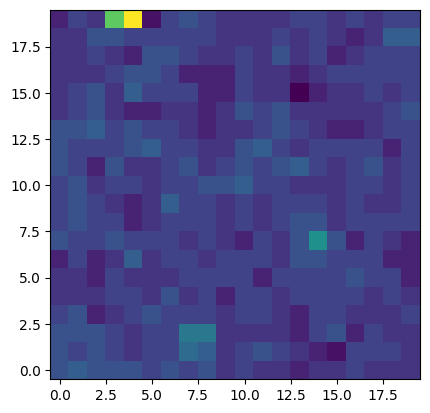

In [11]:
from imageio import imwrite, imread #To be able to use images
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np

dtype = 'float64' #Switch to another dtype to be able to use the higher values
m101 = imread("./Pictures/m101BW.jpg") #rename the image tot m101
darray = np.asarray(m101, dtype=dtype) #I Make it an array

slc = darray[510:530,5:25] #slice a part with one background noise
plt.imshow(slc, origin="lower" ) #show the image
flatdat = slc.flatten() #flatten the data
flatdat2 = flatdat**2 #square the data

rms = np.sqrt(np.sum(flatdat2)/(len(flatdat2))) #calculate the RMS
print(f'The RMS of the data is: {rms}')
print(f'The mean of the data is: {np.mean(flatdat2)}') #calculate the mean
print(f'The STD of the data is: {np.std(flatdat2)}') #calculate the STD

#The RMS measures the differnce in ditances from 0 and the standard diviation measures the distance to the mean
#Since the mean is not 0, bacause there is always some backgroundnoice, the std works better
    


Question 6.5 : Image stack and noise reduction

The STD of the data is: 9.98401556679484
The STD of the data is: 10.003955116338458
The STD of the data is: 9.995349488722516
The STD of the data is: 5.773191380233297
The STD of the data is: 5.7667228164314235


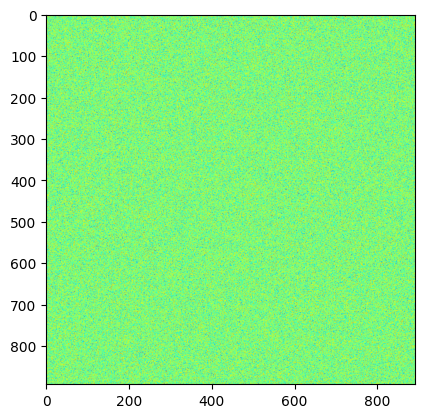

In [47]:
from imageio import imwrite, imread
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
map0 = fits.open("./Downloads/noisemap0.fits") #Open the fits
map1 = fits.open("./Downloads/noisemap1.fits") 
map2 = fits.open("./Downloads/noisemap2.fits") 
dat0 = map0[0].data #Get the data out of the fits
dat1 = map1[0].data
dat2 = map2[0].data
print(f'The STD of the first map is: {np.std(dat0)}') #calculate the STD of the first one
print(f'The STD of the second map is: {np.std(dat1)}') #calculate the STD of the second one
print(f'The STD of the third map is: {np.std(dat2)}') #calculate the STD of the third one


staple = np.stack((dat0, dat1, dat2), axis=0) #staple the maps
total = np.mean(staple, axis=0) #make a new plot with the mean of the backgroundnoise

plt.imshow(total, cmap='jet') #plot the new map

stdtot = np.std(total)
print(f'The STD of the total map is: {stdtot}') #calculate the STD of the new map

std1 = (total - np.mean(flattot))**2 # Use the theoratical formula to calculate the STD
std2 = np.sqrt(np.sum(std1))/len(std1)
print(f'The theoratical STD of the total map is: {std2}') #calculate the theoratical STD


Question 6.6 : FITS Table and table modification

In [36]:
from astropy.io import fits
from astropy.table import Table
import numpy as np

hdul = fits.open('./Downloads/APOGEE_stars.fits') #open the file
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

t = Table(hdul[1].data) #Make a table of the data 

mask = ( #make a mask 
    (t['STARFLAG'] == 0) &
    (t['ASPCAPFLAG'] == 0) &
    (t['SNR'] > 10) &
    (t['GAIAEDR3_PARALLAX'] / t['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(t['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(t['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(t['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

t['DATAFLAG'] = 0 #write a new column, where the value is zero, unless the mask is true, then make it 1
t['DATAFLAG'][mask] = 1

m = t['GAIAEDR3_PHOT_G_MEAN_MAG'] #get the data from the table
par = t['GAIAEDR3_PARALLAX']

truepar = par > 0 #calculate for a positive parallelax, when it is negative the formula doesnt work

M = np.full(len(t), -1.0) #make a new column, with fill in value of 0

M[truepar] = m[truepar] + 5 * np.log10(par[truepar] / 1000.0) + 5 #use the formula

t['ABSOLUTE_MAG'] = np.where(t['DATAFLAG']==1, M, -1.0) #add to the column

t.write('APOGEE_update.fits', format = 'fits', overwrite = True) #make a new fits

print(t)

GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG    ABSOLUTE_MAG   
----------------- ----------------------- ... -------- ------------------
              nan                     nan ...        0               -1.0
       0.28544167                0.019475 ...        0               -1.0
       0.08209286                0.315081 ...        0               -1.0
        1.2985312              0.00952245 ...        0               -1.0
        1.2985312              0.00952245 ...        1 2.7881622314453125
      -0.02394128               0.0450072 ...        0               -1.0
        1.3863556               0.0175672 ...        1 2.9852724075317383
              ...                     ... ...      ...                ...
         4.132398                0.015343 ...        0               -1.0
      0.057267956               0.0597211 ...        0               -1.0
        1.4367273               0.0213831 ...        0               -1.0
       0.42296618               0.0192

Question 6.7 : Exploring GAIA data

    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  
The value for m0 is: 25.68840037029544


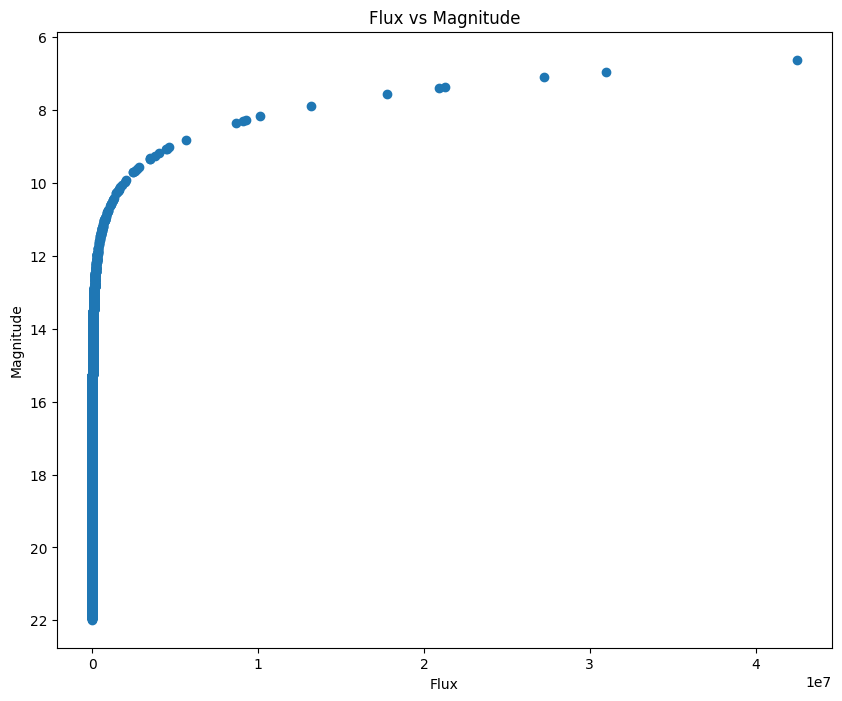

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

t = pd.read_csv('./Downloads/gaiaTestData.csv') #open the file


maxGTD = t["phot_g_mean_flux"] == t["phot_g_mean_flux"].max() #print the row of the max value
print(t[maxGTD])

t.sort_values(["phot_g_mean_flux"], ascending = True) #sort the values

fig, ax = plt.subplots(figsize= (10,8)) #make a plot

ax.scatter(t["phot_g_mean_flux"], t["phot_g_mean_mag"]) #scatter a plot with the flux on the x axis and the mean magnitude on the y-axis


ax.set_title('Flux vs Magnitude') #some nice texts
ax.set_xlabel('Flux')
ax.set_ylabel('Magnitude')
ax.invert_yaxis()

mg = t["phot_g_mean_mag"] #calculate m0
Fg = t["phot_g_mean_flux"]
m0 = mg + 2.5 *np.log10(Fg)
print(f"The value for m0 is: {m0.mean()}")

Question 6.10 : Retrieving data using astroquery

In [24]:
from astroquery.gaia import Gaia
import pandas as pd
query = """ 
SELECT TOP 50
    source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax / parallax_error >5
AND phot_g_mean_mag IS NOT NULL
AND phot_bp_mean_mag IS NOT NULL
AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""
#Gives specific values
job = Gaia.launch_job(query) #makes the 'recipe'
t = job.get_results() #downloads from the server to the computer
tp = t.to_pandas() #converts to panda dataframe
print(t)

t.write("astroquery_gaia.fits", format = 'fits', overwrite = True)


     SOURCE_ID              ra         ... phot_bp_mean_mag phot_rp_mean_mag
                           deg         ...       mag              mag       
------------------- ------------------ ... ---------------- ----------------
4267180339403392768  286.7169128963743 ...        15.942071        14.419943
6709252873623174016     276.6911939192 ...        16.380306        15.151749
4040949706019490560 265.22936348434496 ...        16.118845        13.680644
4517539583701880064 284.02566215626837 ...        16.652264        15.347014
1823532754729083392 300.80580445460237 ...        14.782262        13.795675
3586362911238437248 171.80987737943448 ...        14.809981        12.990531
                ...                ... ...              ...              ...
5631046688815157632 138.49586968485303 ...        17.159462         16.29502
3041605335480028032 113.79875587415445 ...        18.923515        17.105032
4068119119320653568 266.08808554369216 ...        19.989626        17.876837

6.8. More OOP practice

In [34]:

import numpy as np

class fib:
    def __init__(self, maxim, dev, end): #define the names
        self.maximum = maxim
        self.devid = dev
        self.end = end

    def array(self):#make a fobonacci sequence with end value
        seq = [0, 1]
        for i in range(2, self.end):
            seq.append(seq[i-1] + seq[i-2])
        return np.array(seq)

    def divm(self): #make it divideble by a given number
        fibi = self.array() 
        mask = (fibi < self.maximum) & (fibi % self.devid == 0)
        fib_fin = fibi[mask]
        return fib_fin


f = fib(maxim=np.inf, dev=7, end=100)
results = f.divm()

print(f"The Fibonacci numbers smaller than {f.maximum} and divisible by {f.devid} are:")
print(results)

The Fibonacci numbers smaller than inf and divisible by 7 are:
[0 21 987 46368 2178309 102334155 4807526976 225851433717 10610209857723
 498454011879264 23416728348467685 1100087778366101931
 51680708854858323072]
